### Load company stock close price data

In [66]:
from alpha_vantage.timeseries import TimeSeries
import pandas as pd
import time

# Initialize API
api_key = "97OGHWS77V9ZH0G7"
ts = TimeSeries(key=api_key, output_format="pandas")

# Long history tickers (10+ years)
long_term_tickers = ['TSLA', 'TM', 'F', 'GM']  # all NYSE/NASDAQ tickers
short_term_tickers = ['RIVN', 'NIO', 'LCID', 'HYMTF']

# Initialize merged DataFrame
long_term_stock_df = None
short_term_stocks_df = None

# Loop with rate limit protection
for i, ticker in enumerate(long_term_tickers):
    data, _ = ts.get_daily(symbol=ticker, outputsize='full')
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data.columns = [f"{ticker}_{col}" for col in data.columns]
    data['date'] = data.index
    data = data.reset_index(drop=True)
    
    if long_term_stock_df is None:
        long_term_stock_df = data
    else:
        long_term_stock_df = pd.merge(long_term_stock_df, data, on='date', how='outer')

    time.sleep(15)  # Respect Alpha Vantage rate limit
    
# Loop with rate limit protection
for i, ticker in enumerate(short_term_tickers):
    data, _ = ts.get_daily(symbol=ticker, outputsize='full')
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data.columns = [f"{ticker}_{col}" for col in data.columns]
    data['date'] = data.index
    data = data.reset_index(drop=True)
    
    if short_term_stocks_df is None:
        short_term_stocks_df = data
    else:
        short_term_stocks_df = pd.merge(short_term_stocks_df, data, on='date', how='outer')

    time.sleep(15)  # Respect Alpha Vantage rate limit

In [67]:
short_term_stocks_df.head()

,RIVN_1. open,RIVN_2. high,RIVN_3. low,RIVN_4. close,RIVN_5. volume,date,NIO_1. open,NIO_2. high,NIO_3. low,NIO_4. close,...,LCID_1. open,LCID_2. high,LCID_3. low,LCID_4. close,LCID_5. volume,HYMTF_1. open,HYMTF_2. high,HYMTF_3. low,HYMTF_4. close,HYMTF_5. volume
0,NaN,NaN,NaN,NaN,NaN,2016-01-05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,43.15,43.15,43.15,43.15,999.0
1,NaN,NaN,NaN,NaN,NaN,2016-01-06,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,43.15,43.15,43.15,43.15,430.0
2,NaN,NaN,NaN,NaN,NaN,2016-01-07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,39.44,39.44,39.44,39.44,304.0
3,NaN,NaN,NaN,NaN,NaN,2016-01-08,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,39.44,39.44,39.44,39.44,109.0
4,NaN,NaN,NaN,NaN,NaN,2016-01-11,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40.05,40.05,40.05,40.05,683.0


In [117]:
long_term_stock_df = pd.read_csv("ev_stocks_merged_on_date.csv")
short_term_stock_df = pd.read_csv("shortterm_ev_stocks_ts.csv")
long_term_stock_df = long_term_stock_df.sort_values(by="date")
short_term_stock_df = short_term_stocks_df.sort_values(by="date")
short_term_stock_df.head()

,RIVN_1. open,RIVN_2. high,RIVN_3. low,RIVN_4. close,RIVN_5. volume,date,NIO_1. open,NIO_2. high,NIO_3. low,NIO_4. close,...,LCID_1. open,LCID_2. high,LCID_3. low,LCID_4. close,LCID_5. volume,HYMTF_1. open,HYMTF_2. high,HYMTF_3. low,HYMTF_4. close,HYMTF_5. volume
0,NaN,NaN,NaN,NaN,NaN,2016-01-05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,43.15,43.15,43.15,43.15,999.0
1,NaN,NaN,NaN,NaN,NaN,2016-01-06,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,43.15,43.15,43.15,43.15,430.0
2,NaN,NaN,NaN,NaN,NaN,2016-01-07,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,39.44,39.44,39.44,39.44,304.0
3,NaN,NaN,NaN,NaN,NaN,2016-01-08,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,39.44,39.44,39.44,39.44,109.0
4,NaN,NaN,NaN,NaN,NaN,2016-01-11,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,40.05,40.05,40.05,40.05,683.0


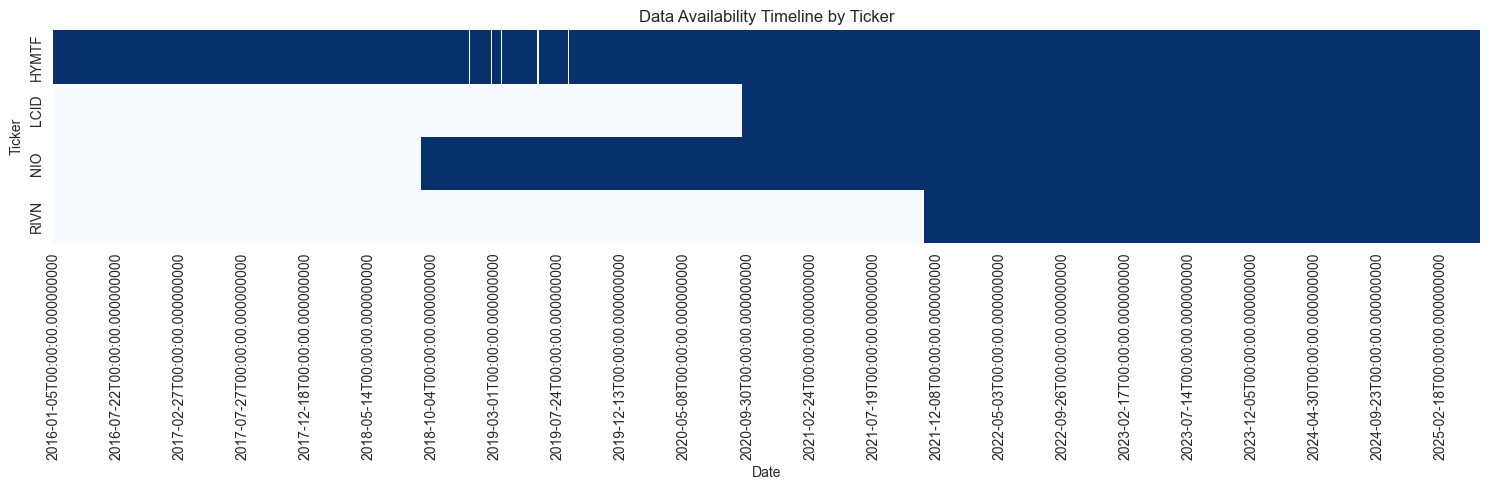

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

def clean_df(merged_df):
    # Extract just the columns with closing prices (or choose any consistent column)
    close_cols = [col for col in merged_df.columns if 'close' in col.lower()]
    date_range_df = merged_df[['date'] + close_cols].copy()
    date_range_df['date'] = pd.to_datetime(date_range_df['date'])
    
    # Melt to long format: one row per (date, ticker)
    melted = date_range_df.melt(id_vars='date', var_name='ticker', value_name='value')
    
    # Clean ticker names for display
    melted['ticker'] = melted['ticker'].str.extract(r'(^[^_]+)')
    
    # Create pivot table: 1 if value exists, 0 if NaN
    presence = melted.pivot_table(index='ticker', columns='date', values='value', aggfunc='count').fillna(0)
    return presence

presence_lt = clean_df(long_term_stock_df)
presence_st = clean_df(short_term_stock_df)

# Plot
plt.figure(figsize=(15, 5))
sns.heatmap(presence_lt, cmap='Greens', cbar=False, xticklabels=100)
sns.heatmap(presence_st, cmap='Blues', cbar=False, xticklabels=100)
plt.title("Data Availability Timeline by Ticker")
plt.xlabel("Date")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

In [119]:
# long_term_stock_df = long_term_stock_df.dropna().set_index('date')
short_term_stock_df = short_term_stock_df.dropna().set_index('date')
short_term_stock_df.head()

,RIVN_1. open,RIVN_2. high,RIVN_3. low,RIVN_4. close,RIVN_5. volume,NIO_1. open,NIO_2. high,NIO_3. low,NIO_4. close,NIO_5. volume,LCID_1. open,LCID_2. high,LCID_3. low,LCID_4. close,LCID_5. volume,HYMTF_1. open,HYMTF_2. high,HYMTF_3. low,HYMTF_4. close,HYMTF_5. volume
date,,,,,,,,,,,,,,,,,,,,
2021-11-10,106.750,119.4600,95.20,100.73,103679466.0,40.89,42.09,38.8300,39.55,48507260.0,42.30,45.00,39.3405,40.75,79342771.0,41.70,41.70,41.2200,41.4100,1977.0
2021-11-11,114.625,125.0000,108.01,122.99,83668202.0,40.89,42.22,40.3535,42.20,39933984.0,42.75,45.75,41.7400,44.98,69846270.0,41.80,42.00,41.8000,41.8000,2144.0
2021-11-12,128.645,135.2000,125.25,129.95,50345677.0,42.69,43.55,41.9100,42.67,34492479.0,44.00,45.19,42.7400,43.93,40614373.0,42.00,42.09,42.0000,42.0900,927.0
2021-11-15,130.800,152.5300,127.51,149.36,64982343.0,42.60,42.69,40.0200,40.57,47571747.0,44.60,46.14,43.4100,44.88,77111001.0,42.42,42.42,41.7835,41.9999,5286.0
2021-11-16,163.800,179.4699,153.78,172.01,94036577.0,40.89,41.30,40.0200,40.67,37098978.0,49.93,55.68,46.5086,55.52,248654643.0,41.75,41.75,41.3200,41.5500,4307.0


### Load ESG Data

In [120]:
esg = pd.read_csv("data/ESG World Bank Data/esg_data.csv")
environ = pd.read_csv("data/World Bank Environmental Data/environment.csv", skiprows=3)

# Reshape the ESG data into a long format
esg = esg.drop(columns='Series Code')
esg = esg.rename(columns={'Series Name': 'Indicator Name'})
esg_long = esg.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='Value'
)
# Clean the 'Year' column to extract the numeric year
esg_long['Year'] = esg_long['Year'].str.extract(r'(\d{4})')

# Replace '..' with NaN to ensure missing values are correctly identified
esg_long['Value'] = pd.to_numeric(esg_long['Value'], errors='coerce')
esg_long.replace('..', pd.NA, inplace=True)
esg_long = esg_long.dropna(subset=['Value'])

# Select only the relevant countries (US, UK, China, EU countries: Germany, France, Netherlands, Sweden, etc.)
relevant_countries = ['United States', 'United Kingdom', 'China', 'Germany', 'France', 'Norway', 'Canada', 'Japan', 'South Korea', 'Netherlands', 'Sweden', 'Australia']

# Filter the ESG data
esg_df = esg_long[esg_long['Country Name'].isin(relevant_countries)]

# Environment dataset processing
environ = environ.drop(columns='Indicator Code')
environ_long = environ.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='Value'
)
# Replace '..' with NaN to ensure missing values are correctly identified
environ_long.replace('..', pd.NA, inplace=True)
environ_long = environ_long.dropna(subset=['Value'])

# Filter the Environmental data for the relevant countries
environ_df = environ_long[environ_long['Country Name'].isin(relevant_countries)]

# Print a summary of the filtered datasets
esg_df.head()
environ_df.head()

,Country Name,Country Code,Indicator Name,Year,Value
1973,Australia,AUS,Total fisheries production (metric tons),1960,6.134500e+04
1974,Australia,AUS,Capture fisheries production (metric tons),1960,5.564500e+04
1975,Australia,AUS,Aquaculture production (metric tons),1960,5.700000e+03
2035,Australia,AUS,"Electricity production from renewable sources,...",1960,1.412653e+00
2036,Australia,AUS,"Electricity production from renewable sources,...",1960,3.030000e+08


In [121]:
# For esg_df
esg_indicators = ['Research and development expenditure (% of GDP)',
                  'Net migration',
                  'Electricity production from coal sources (% of total)', 
                  'Renewable energy consumption (% of total final energy consumption)',
                  'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
                  'GDP growth (annual %)', 
                  'Patent applications, residents',
                  'Regulatory Quality: Estimate'] 
# For environ_df
environ_indicators = ['Nitrous oxide (N2O) emissions from Transport (Energy) (Mt CO2e)'] 

country_indicators = ['United States', 'China', 'Japan', 'Netherlands']

In [122]:
# Filter the ESG data for relevant indicators
esg_df = esg_df[esg_df['Indicator Name'].isin(esg_indicators)]

# Filter the Environmental data for relevant indicators
environ_df = environ_df[environ_df['Indicator Name'].isin(environ_indicators)]

# Combine the ESG and Environmental datasets
combined_df = pd.concat([esg_df, environ_df], ignore_index=True)

# Sort the data for better readability
esg_df = combined_df.sort_values(by=['Country Name', 'Year', 'Indicator Name'])

esg_df = esg_df[esg_df['Country Name'].isin(country_indicators)]
esg_df

,Country Name,Country Code,Indicator Name,Year,Value
3000,China,CHN,Nitrous oxide (N2O) emissions from Transport (...,1970,0.174300
3011,China,CHN,Nitrous oxide (N2O) emissions from Transport (...,1971,0.174500
3022,China,CHN,Nitrous oxide (N2O) emissions from Transport (...,1972,0.191500
3033,China,CHN,Nitrous oxide (N2O) emissions from Transport (...,1973,0.204900
6,China,CHN,Electricity production from coal sources (% of...,1974,56.780938
...,...,...,...,...,...
2975,United States,USA,Research and development expenditure (% of GDP),2021,3.457050
2996,United States,USA,GDP growth (annual %),2022,1.935635
3580,United States,USA,Nitrous oxide (N2O) emissions from Transport (...,2022,21.367400
2997,United States,USA,Regulatory Quality: Estimate,2022,1.424440


Load ETF Commodity Data

In [123]:
import pandas as pd

metal_etfs = pd.read_csv('data/AlphaVantage Metal ETFS/metal_etfs.csv')
JJN_cols = [col for col in metal_etfs.columns if 'JJN' in col.upper()]
JJC_cols = [col for col in metal_etfs.columns if 'JJC' in col.upper()]
metal_etfs = metal_etfs.rename(columns={'Unnamed: 0': 'date'}).drop(columns=JJN_cols + JJC_cols)
metal_etfs.head()

,date,LIT_open,LIT_high,LIT_low,LIT_close,LIT_volume,COPX_open,COPX_high,COPX_low,COPX_close,...,DBB_open,DBB_high,DBB_low,DBB_close,DBB_volume,PICK_open,PICK_high,PICK_low,PICK_close,PICK_volume
0,2007-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.10,24.10,23.30,23.7100,184600.0,NaN,NaN,NaN,NaN,NaN
1,2007-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.11,34.11,23.39,23.3900,10200.0,NaN,NaN,NaN,NaN,NaN
2,2007-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.90,23.39,22.90,23.2699,4700.0,NaN,NaN,NaN,NaN,NaN
3,2007-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.55,24.22,23.55,24.2200,10900.0,NaN,NaN,NaN,NaN,NaN
4,2007-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24.05,24.85,24.05,24.5400,116100.0,NaN,NaN,NaN,NaN,NaN


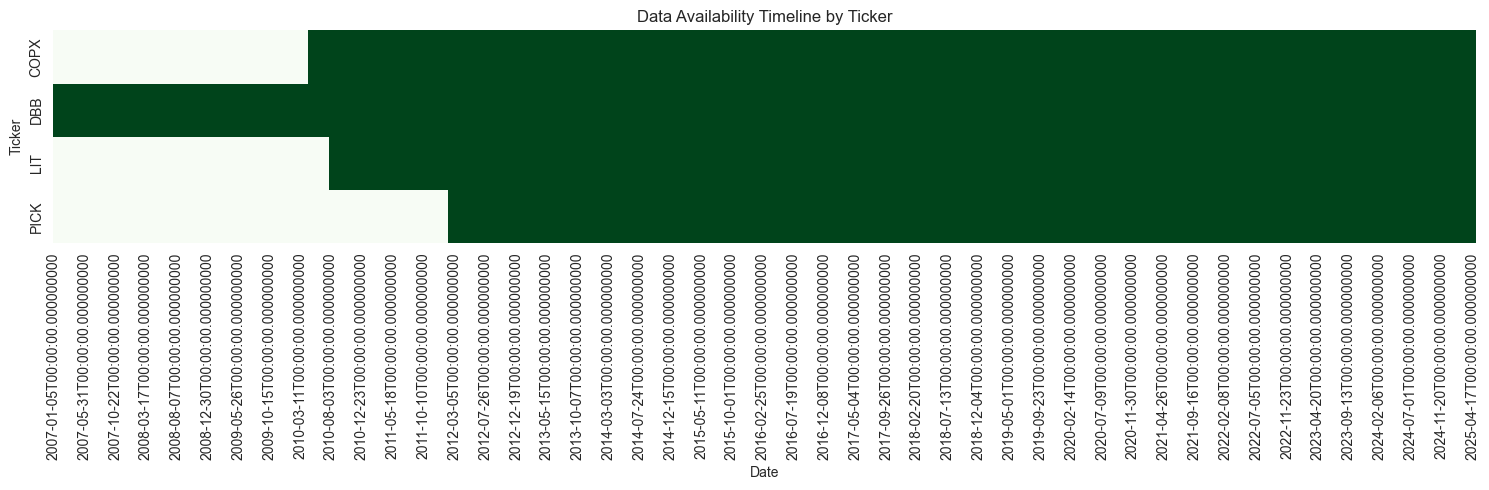

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract just the columns with closing prices (or choose any consistent column)
close_cols = [col for col in metal_etfs.columns if 'close' in col.lower()]
date_range_df = metal_etfs[['date'] + close_cols].copy()
date_range_df['date'] = pd.to_datetime(date_range_df['date'])

# Melt to long format: one row per (date, ticker)
melted = date_range_df.melt(id_vars='date', var_name='ticker', value_name='value')

# Clean ticker names for display
melted['ticker'] = melted['ticker'].str.extract(r'(^[^_]+)')

# Create pivot table: 1 if value exists, 0 if NaN
presence = melted.pivot_table(index='ticker', columns='date', values='value', aggfunc='count').fillna(0)

# Plot
plt.figure(figsize=(15, 5))
sns.heatmap(presence, cmap='Greens', cbar=False, xticklabels=100)
plt.title("Data Availability Timeline by Ticker")
plt.xlabel("Date")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

Cleaned Data

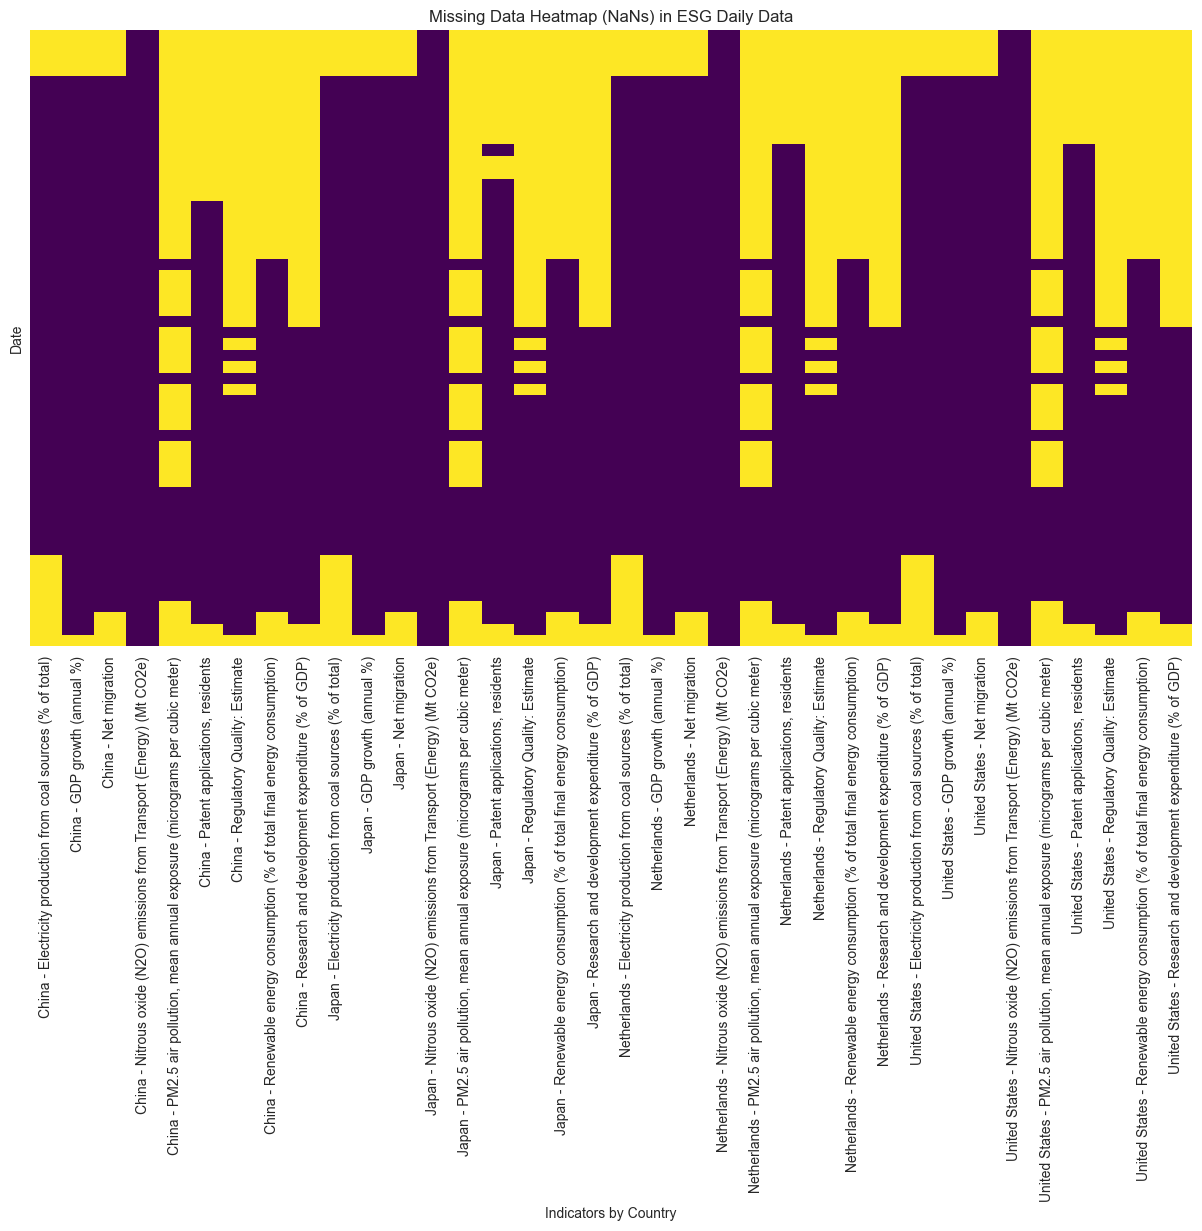

In [125]:
# esg_df = esg_df.drop(columns='Country Code')

daily_rows = []
for _, row in esg_df.iterrows():
    year = row['Year']
    dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31', freq='D')
    repeated_rows = pd.DataFrame([row.drop('Year').values] * len(dates),
                                 columns=row.drop('Year').index, index=dates)
    daily_rows.append(repeated_rows)

esg_daily_df = pd.concat(daily_rows)

esg_daily_df['combo'] = esg_daily_df['Country Name'] + ' - ' + esg_daily_df['Indicator Name']
wide_esg = esg_daily_df.pivot_table(values='Value', index=esg_daily_df.index, 
                                   columns='combo', aggfunc='first')
wide_esg.columns.name = None
wide_esg

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(wide_esg.isna(), 
            cbar=False, 
            yticklabels=False, 
            cmap='viridis')  # 'viridis' for a cool color gradient showing NaNs

plt.title("Missing Data Heatmap (NaNs) in ESG Daily Data")
plt.xlabel("Indicators by Country")
plt.ylabel("Date")
plt.show()

In [129]:
#metal_etfs = metal_etfs.dropna().set_index('date')
#long_term_stock_df = long_term_stock_df.dropna().set_index('date')
#short_term_stock_df = short_term_stock_df.dropna().set_index('date')
long_term_stock_df.head()

,TSLA_1. open,TSLA_2. high,TSLA_3. low,TSLA_4. close,TSLA_5. volume,TM_1. open,TM_2. high,TM_3. low,TM_4. close,TM_5. volume,F_1. open,F_2. high,F_3. low,F_4. close,F_5. volume,GM_1. open,GM_2. high,GM_3. low,GM_4. close,GM_5. volume
date,,,,,,,,,,,,,,,,,,,,
2010-11-18,30.67,30.74,28.9201,29.89,956100.0,77.36,77.51,76.83,77.29,989100.0,16.77,16.87,16.05,16.12,256937900.0,35.00,35.99,33.89,34.19,457044300.0
2010-11-19,30.16,31.37,29.7000,30.99,1150500.0,78.04,78.47,77.46,78.47,957700.0,16.02,16.38,15.83,16.28,130323600.0,34.15,34.50,33.11,34.26,107842000.0
2010-11-22,31.57,33.45,31.5000,33.40,1529700.0,78.36,78.67,77.79,78.47,647000.0,16.26,16.54,16.11,16.20,91288900.0,34.20,34.48,33.81,34.08,36650600.0
2010-11-23,33.29,35.68,32.1901,34.57,1577800.0,77.41,78.36,77.08,77.43,627100.0,16.01,16.16,15.62,15.70,96689100.0,33.95,33.99,33.19,33.25,31170200.0
2010-11-24,35.27,35.97,34.3340,35.47,1425000.0,78.47,78.97,78.25,78.93,654000.0,15.95,16.06,15.81,15.95,66727700.0,33.73,33.80,33.22,33.48,26138000.0


Feature Engineering

In [142]:
# Convert EV stock prices to returns (like 1-day returns)
ev_returns = long_term_stock_df.pct_change().dropna()
df = metal_etfs.join(ev_returns, how='inner').dropna()
df.head()

,LIT_open,LIT_high,LIT_low,LIT_close,LIT_volume,COPX_open,COPX_high,COPX_low,COPX_close,COPX_volume,...,F_1. open,F_2. high,F_3. low,F_4. close,F_5. volume,GM_1. open,GM_2. high,GM_3. low,GM_4. close,GM_5. volume
date,,,,,,,,,,,,,,,,,,,,,
2012-02-02,17.00,17.140,16.987,17.1000,14800.0,15.36,15.6000,15.36,15.46,57800.0,...,-0.025923,-0.025098,-0.007323,-0.005677,-0.325404,0.013152,0.004475,0.009555,-0.002462,-0.499839
2012-02-03,17.44,17.450,17.100,17.4300,35800.0,15.68,15.8200,15.62,15.78,68100.0,...,0.005645,0.032985,0.015574,0.043230,0.630923,0.014199,0.070879,0.020165,0.076923,2.826785
2012-02-06,17.21,17.329,17.150,17.2500,19400.0,15.57,15.6600,15.47,15.59,67500.0,...,0.030473,0.012461,0.025827,0.013292,-0.412015,0.058800,0.014750,0.046793,0.019862,-0.323722
2012-02-07,17.30,17.370,17.250,17.2699,13800.0,15.41,15.4676,15.22,15.28,48100.0,...,0.006226,-0.002308,0.009441,-0.006173,-0.149899,0.005667,-0.007827,0.007707,-0.017978,-0.376504
2012-02-08,17.42,17.440,17.220,17.4000,39600.0,15.46,15.5560,15.27,15.30,88600.0,...,-0.001547,-0.000771,-0.002338,-0.003106,-0.103036,-0.011645,-0.007513,-0.021797,-0.017925,0.628032


In [149]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# define feature and target columns
features = metal_etfs.columns.tolist()
targets = ev_returns.columns.tolist()

# Features and targets (no windows)
X = np.array(df[features])
y = np.array(df[targets])

# Train/test split (e.g. 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)  # no shuffle in time series!
alphas=np.linspace(-100, 100, 200)
# Fit Ridge regression
ridge = Ridge(alpha=alphas)
ridge.fit(X_train, y_train)

# Predict and evaluate
y_pred = ridge.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Baseline Ridge Regression MAE: {mae:.5f}")

ValueError: Number of targets and number of penalties do not correspond: 200 != 20

In [146]:
import numpy as np
import pandas as pd

# define feature and target columns
features = metal_etfs.columns.tolist()
targets = ev_returns.columns.tolist()

# create sliding windows for features and next-day targets
window_size = 10

X_windows = []
y_targets = []

for i in range(len(df) - window_size - 1):
    X_window = df[features].iloc[i:i+window_size].values  # shape (window_size, n_features)
    y_target = df[targets].iloc[i + window_size + 1].values  # predict 1 day ahead returns
    X_windows.append(X_window)
    y_targets.append(y_target)

# Convert to numpy arrays
X_windows = np.array(X_windows)  # (samples, window_size, n_features)
y_targets = np.array(y_targets)  # (samples, n_targets)

print(f"Feature windows shape: {X_windows.shape}")
print(f"Target returns shape: {y_targets.shape}")

Feature windows shape: (3324, 10, 20)
Target returns shape: (3324, 20)


In [144]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_windows, y_targets, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1])  # output layer for multi-stock regression (linear activation)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Evaluate on test
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.5f}")


/Users/zoetomlinson/miniconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1821 - mae: 0.3121 - val_loss: 0.0525 - val_mae: 0.1212
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0633 - mae: 0.1392 - val_loss: 0.0476 - val_mae: 0.0967
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0577 - mae: 0.1120 - val_loss: 0.0464 - val_mae: 0.0894
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0564 - mae: 0.0998 - val_loss: 0.0460 - val_mae: 0.0855
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0536 - mae: 0.0931 - val_loss: 0.0458 - val_mae: 0.0830
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0479 - mae: 0.0872 - val_loss: 0.0457 - val_mae: 0.0811
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0535 - mae: 0.0862 - val_loss: 0.0456 - val_mae: 0.0800
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0502 - mae: 0.0845 - val_loss: 0.0456 - val_mae: 0.0792
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0526 - mae: 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Convert prices to daily returns
ev_returns = long_term_stock_df.pct_change().dropna()

# Step 2: Keep only columns that include 'close'
close_columns = [col for col in ev_returns.columns if 'close' in col.lower()]
ev_returns_close = ev_returns[close_columns]

# Optional: standardize metal ETF features
X = (metal_etfs - metal_etfs.mean()) / metal_etfs.std()

results = {}

for stock in ev_returns_close.columns:
    y = ev_returns_close[stock]

    # Align X and y (in case dates mismatch)
    Xy = pd.concat([X, y], axis=1).dropna()
    X_clean = Xy[X.columns]
    y_clean = Xy[stock]

    # Train/test split (keep time order!)
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, shuffle=False
    )

    # Grid search over alpha
    param_grid = {'alpha': np.logspace(-3, 3, 50)}
    ridge = Ridge()
    grid = GridSearchCV(ridge, param_grid, cv=5)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[stock] = {
        'best_alpha': grid.best_params_['alpha'],
        'mae': mae,
        'r2': r2
    }

# Display results
print("\n=== Ridge Regression Results ===")
for stock, res in results.items():
    print(f"{stock:<20} | Alpha: {res['best_alpha']:.4f} | MAE: {res['mae']:.5f} | R²: {res['r2']:.5f}")